In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import os
import re

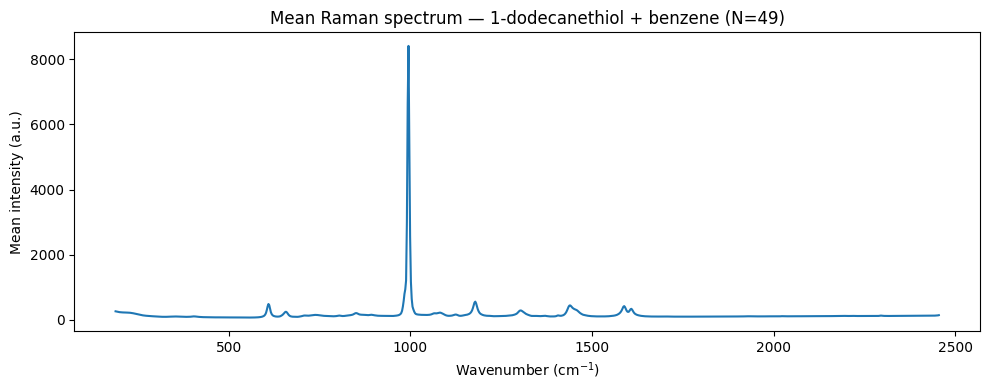

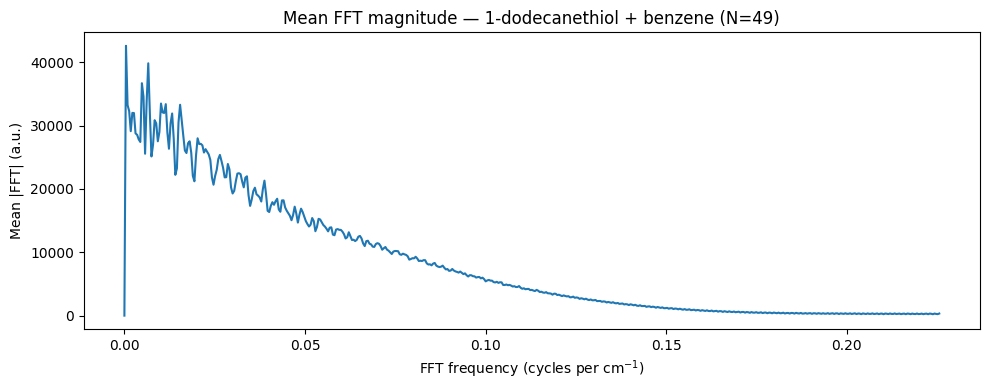

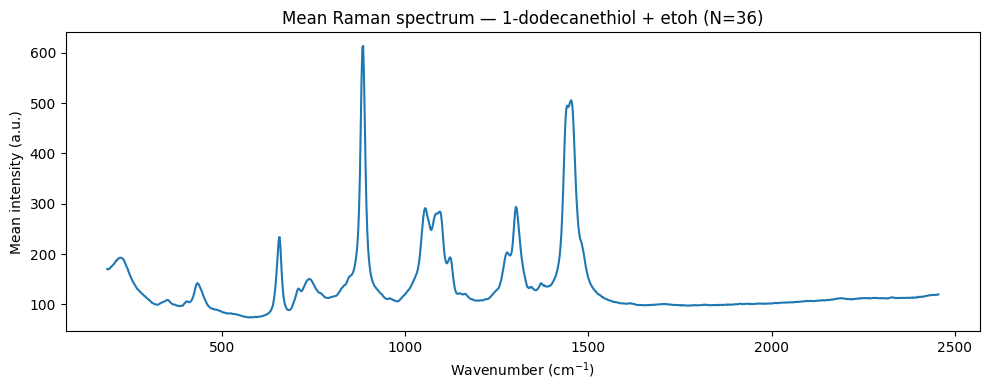

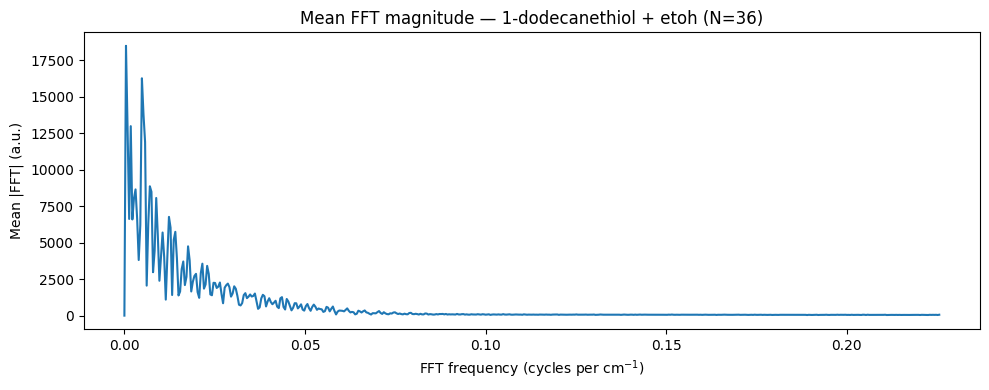

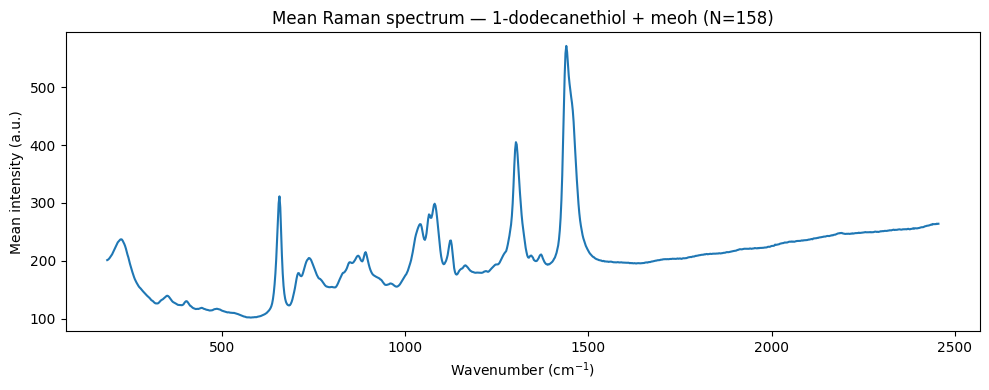

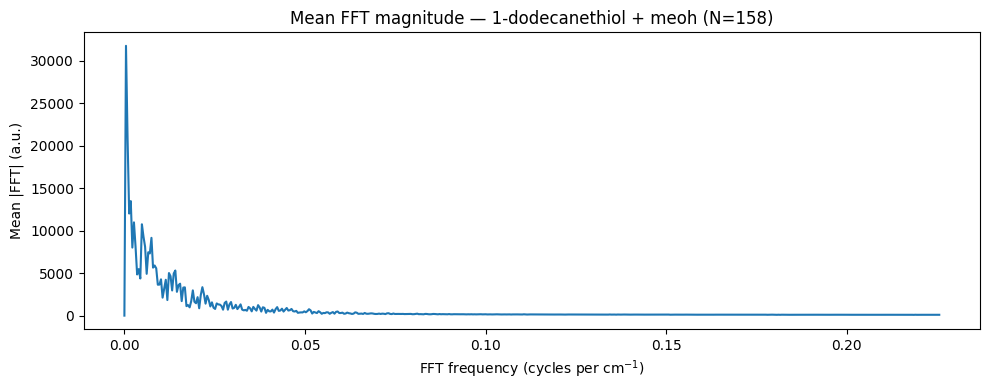

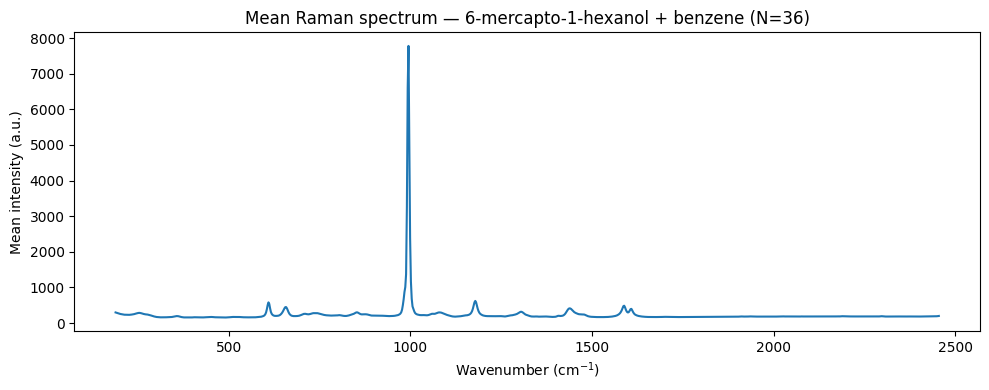

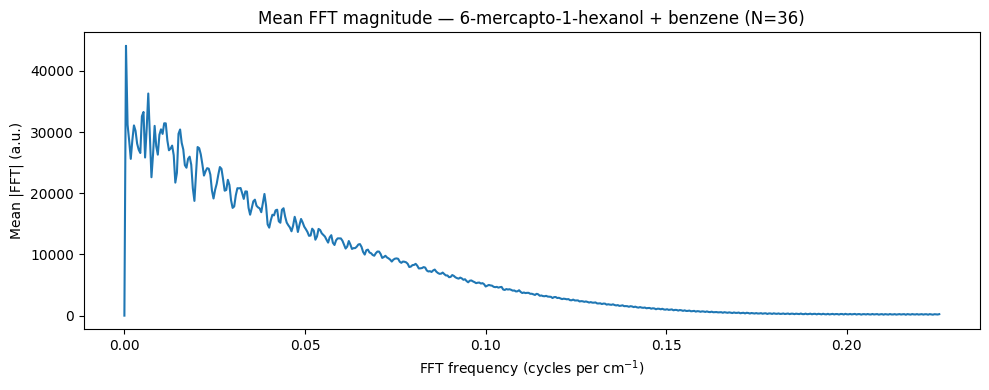

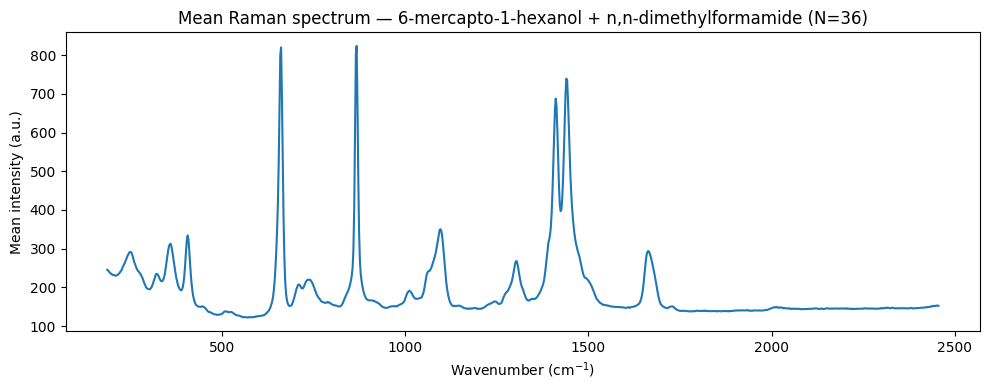

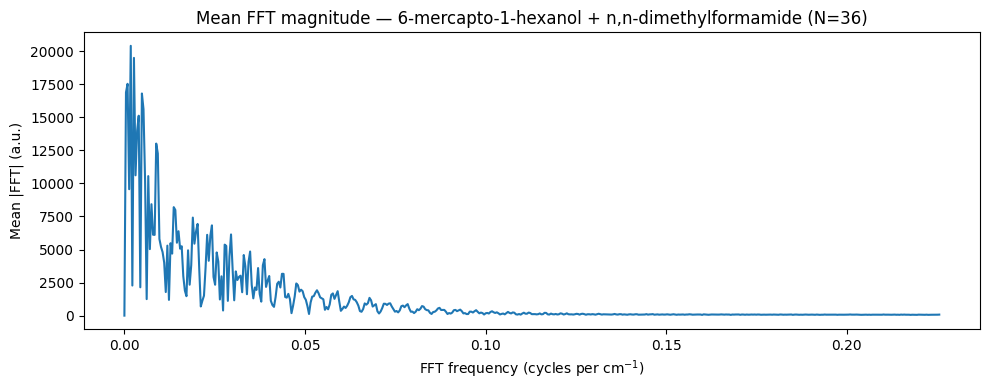

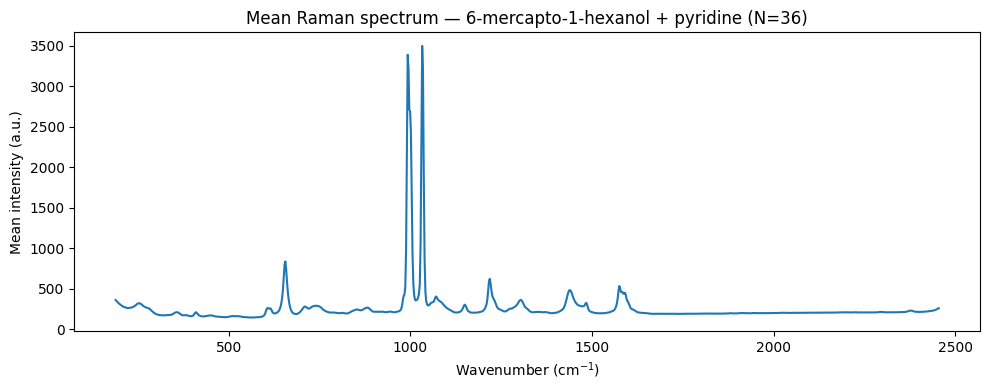

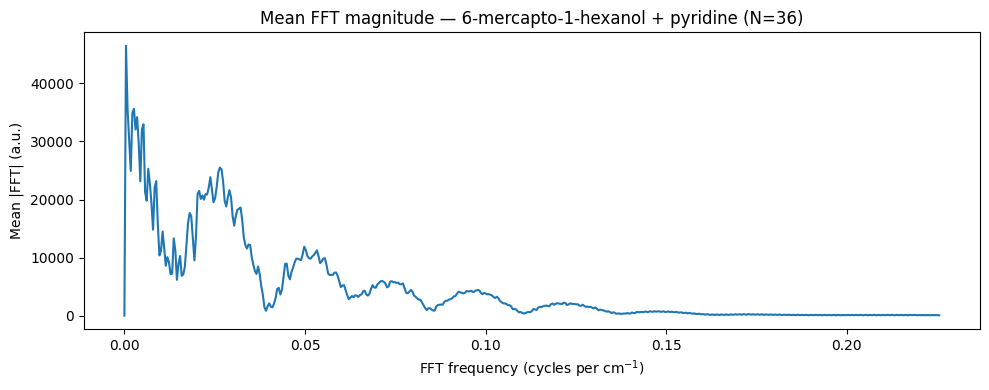

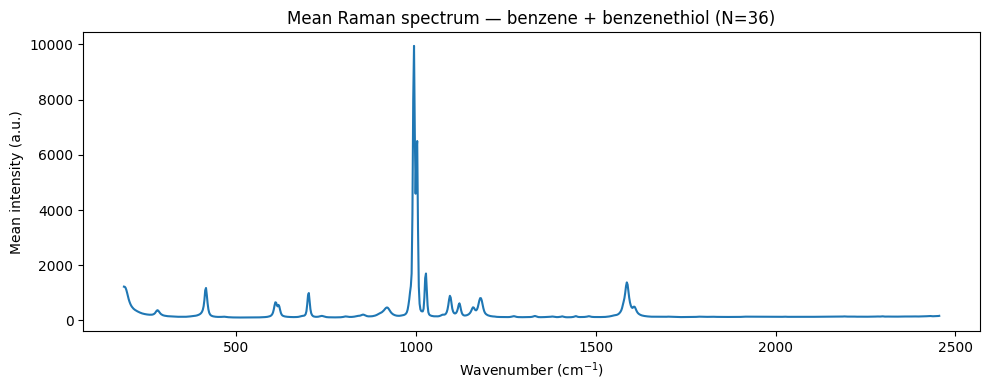

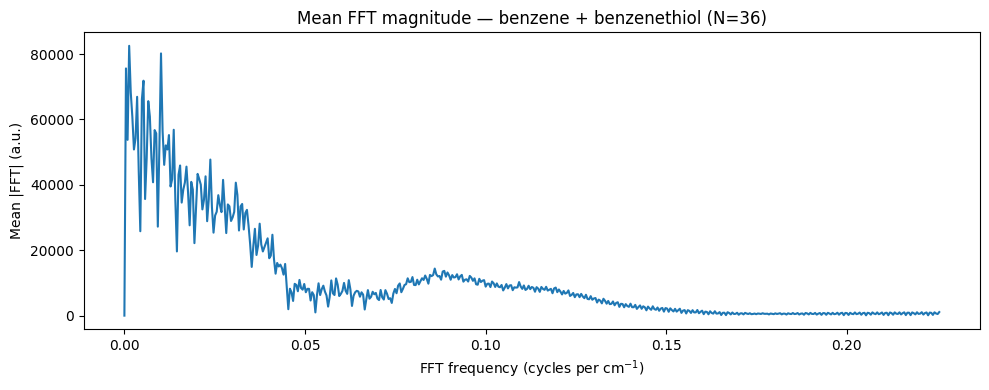

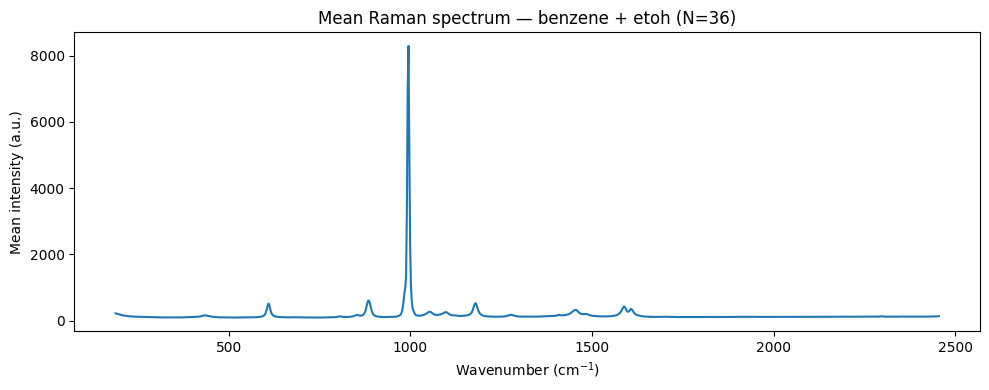

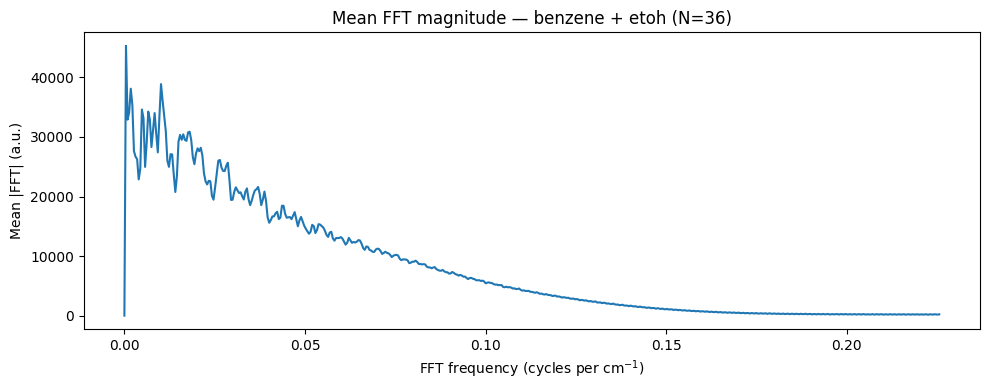

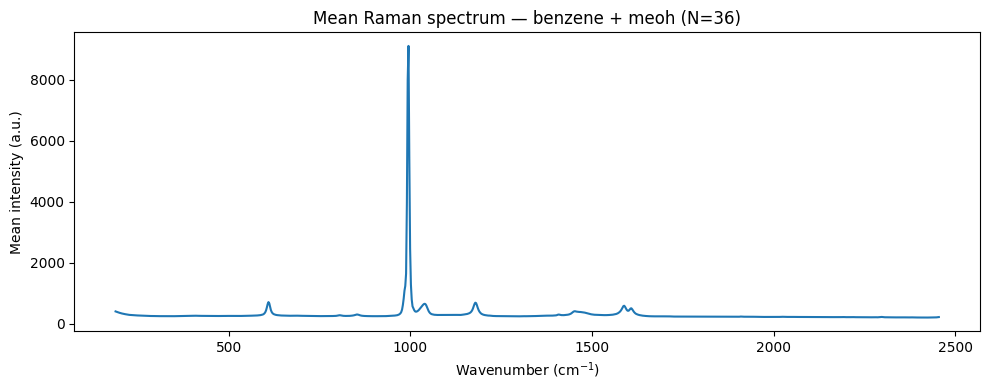

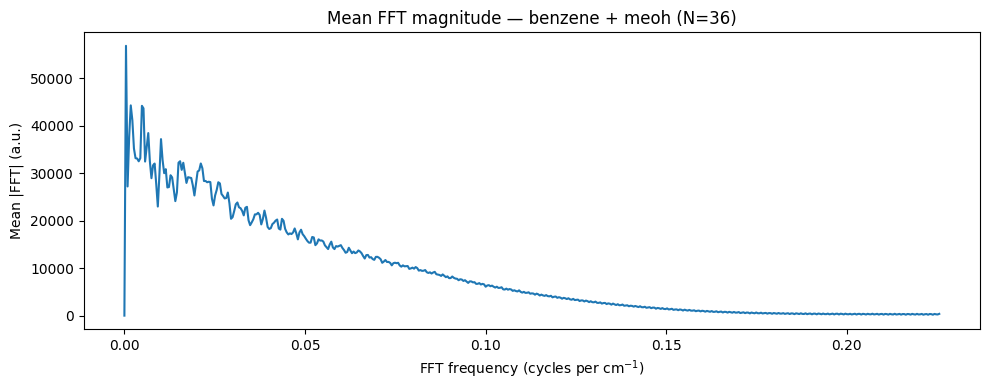

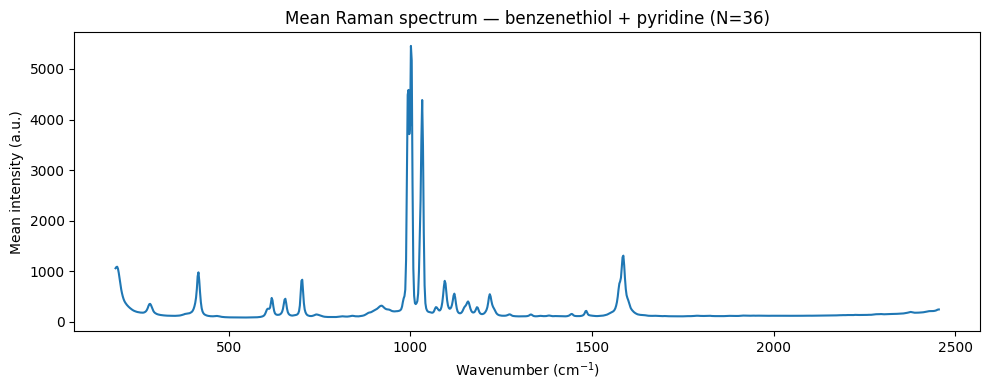

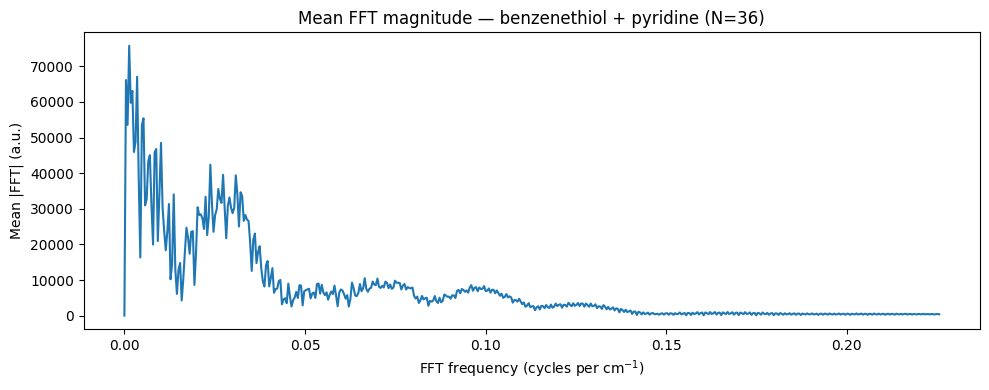

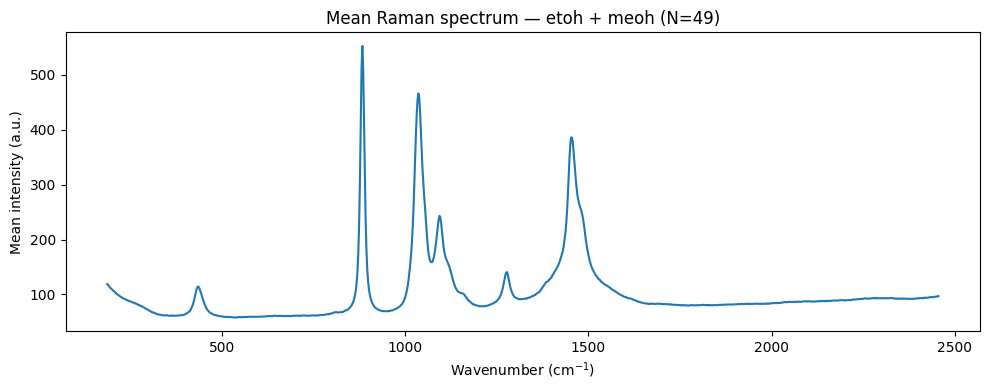

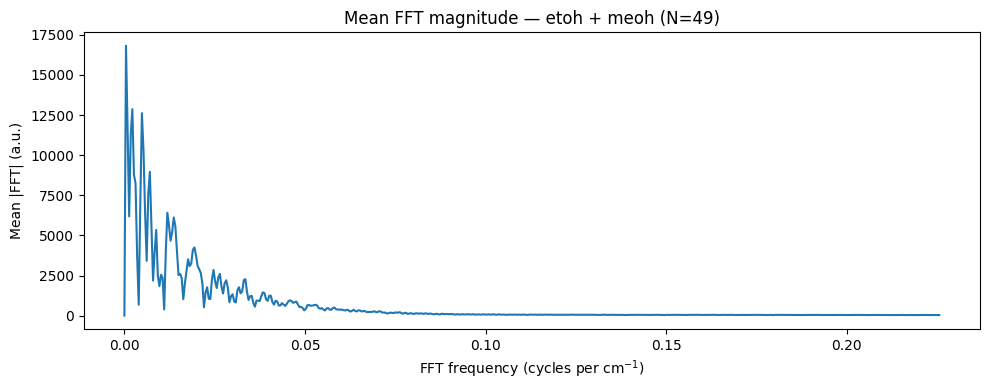

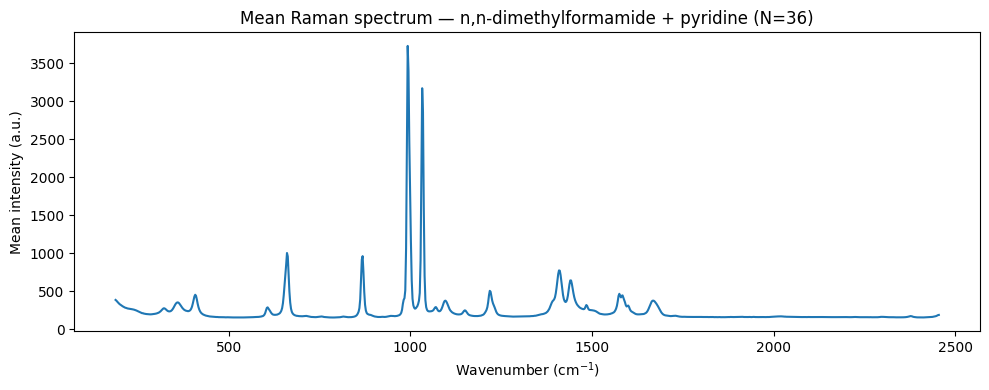

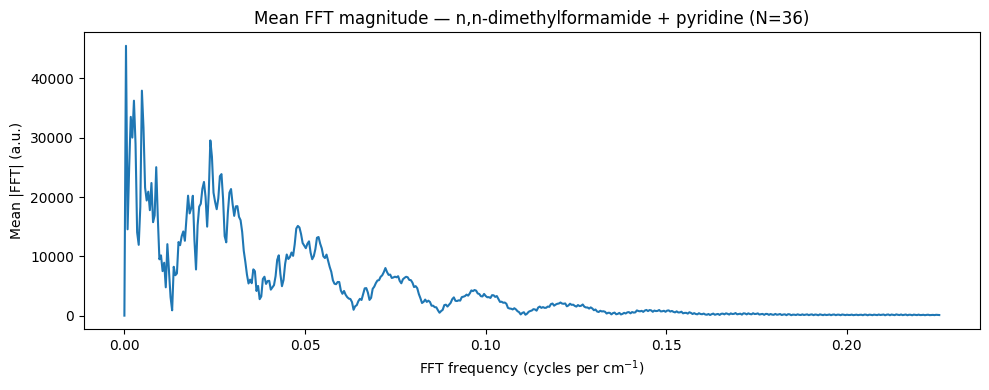

Saved to: mixture_pair_plots


In [10]:
path = 'mixtures_dataset.csv'
df = pd.read_csv(path)

# Separate spectral columns (wavenumbers) and labels
label_cols = ["Label 1", "Label 2"]
spec_cols = [c for c in df.columns if c not in label_cols]

# Ensure wavenumbers are in ascending numeric order
wavenumbers = np.array([float(c) for c in spec_cols])
order = np.argsort(wavenumbers)
wavenumbers = wavenumbers[order]
spec_cols = [spec_cols[i] for i in order]

X = df[spec_cols].to_numpy(dtype=float)

# Define an unordered pair key (so A+B matches B+A)
pair_key = df[label_cols].apply(
    lambda r: " + ".join(sorted((r["Label 1"], r["Label 2"]))),
    axis=1
)

# FFT settings
n = X.shape[1]
dx = float(np.mean(np.diff(wavenumbers)))  # approximate uniform spacing in cm^-1
freq = np.fft.rfftfreq(n, d=dx)            # cycles per (cm^-1)

# --- Output control (no PdfPages) ---
SAVE_PNGS = True          # set False if you only want to display plots
SHOW_PLOTS = True         # set False if you're running headless / only saving
out_dir = "mixture_pair_plots"
if SAVE_PNGS:
    os.makedirs(out_dir, exist_ok=True)

def safe_name(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]+", "_", s).strip("_")

summary = []

for pair, idx in pair_key.groupby(pair_key).groups.items():
    Xi = X[np.array(list(idx))]

    # Average Raman spectrum
    mean_spec = Xi.mean(axis=0)

    # Average FFT magnitude (remove per-sample DC first to focus on structure)
    Xi_demean = Xi - Xi.mean(axis=1, keepdims=True)
    mag = np.abs(np.fft.rfft(Xi_demean, axis=1))
    mean_mag = mag.mean(axis=0)

    summary.append({"Pair": pair, "N samples": len(idx)})

    tag = safe_name(pair)

    # Plot 1: Mean spectrum
    plt.figure(figsize=(10, 4))
    plt.plot(wavenumbers, mean_spec)
    plt.xlabel("Wavenumber (cm$^{-1}$)")
    plt.ylabel("Mean intensity (a.u.)")
    plt.title(f"Mean Raman spectrum — {pair} (N={len(idx)})")
    plt.tight_layout()
    if SAVE_PNGS:
        plt.savefig(os.path.join(out_dir, f"{tag}__mean_spectrum.png"), dpi=200)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

    # Plot 2: Mean FFT magnitude
    plt.figure(figsize=(10, 4))
    plt.plot(freq, mean_mag)
    plt.xlabel("FFT frequency (cycles per cm$^{-1}$)")
    plt.ylabel("Mean |FFT| (a.u.)")
    plt.title(f"Mean FFT magnitude — {pair} (N={len(idx)})")
    plt.tight_layout()
    if SAVE_PNGS:
        plt.savefig(os.path.join(out_dir, f"{tag}__mean_fft_mag.png"), dpi=200)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

summary_df = (
    pd.DataFrame(summary)
    .sort_values(["N samples", "Pair"], ascending=[False, True])
    .reset_index(drop=True)
)


print("Saved to:", out_dir if SAVE_PNGS else "(not saving)")